# Experiment: Song Fingerprinting Experiments (Colab)

Objective:
- Train and compare a compact spectrogram CNN, a hybrid spectrogram transformer, and a frozen `m-a-p/MERT-v1-95M` baseline for contrastive song fingerprinting on FMA Small.
- Evaluate exact FAISS retrieval under clean, noisy, pitch-shifted, time-stretched, low-pass, and high-pass queries.
- Success criteria: the notebook runs top-to-bottom in Google Colab, saves checkpoints, metrics, and plots, and produces non-random Top-k retrieval for every enabled run.

## Checklist

- [ ] Environment installed and versions verified
- [ ] Reproducibility configured from one typed config block
- [ ] FMA metadata and audio downloaded into `/content/data`
- [ ] Track-level train, validation, and test split verified from `tracks.csv`
- [ ] Clean and augmented examples visualized
- [ ] Dataset smoke tests completed for CNN, hybrid transformer, and MERT
- [ ] Experiments trained in the fixed execution order
- [ ] FAISS retrieval evaluated under clean and degraded queries
- [ ] Metrics, checkpoints, plots, and zipped artifacts saved to `/content/song_fingerprinting_outputs`

In [1]:
# Setup: install notebook dependencies directly in the active Colab runtime.
# Colab already ships PyTorch, torchaudio, and torchvision on GPU runtimes,
# so this cell upgrades the non-core packages that the experiment depends on.
from __future__ import annotations

import subprocess
import sys

REQUIRED_PIP_SPECS: list[str] = [
    "accelerate>=1.10.0",
    "transformers>=4.57.0",
    "librosa>=0.10.2",
    "soundfile>=0.13.1",
    "scikit-learn>=1.5.0",
    "faiss-cpu>=1.12.0",
    "tqdm>=4.67.0",
    "matplotlib>=3.9.0",
    "pandas>=2.2.0",
    "numpy>=2.0.0",
    "scipy>=1.13.0",
]


def install_required_packages(specs: list[str]) -> None:
    """Install the requested packages into the current notebook kernel."""
    if not specs:
        print("No additional packages requested.")
        return
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *specs])


install_required_packages(REQUIRED_PIP_SPECS)
print("Dependency installation complete.")


Dependency installation complete.


In [ ]:
from pathlib import Path
from datetime import datetime
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

PERSISTENT_NOTEBOOK2_ROOT = Path("/content/drive/MyDrive/transformer_fingerprinting/artifacts/notebook2")
PERSISTENT_NOTEBOOK2_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Persistent artifact root: {PERSISTENT_NOTEBOOK2_ROOT}")

In [2]:
# Setup: imports, version reporting, and deterministic seeding.
from __future__ import annotations

import ast
import gc
import json
import math
import os
import platform
import random
import shutil
import subprocess
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable, Literal, TypedDict

import faiss
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from IPython.display import display
from torch.utils.checkpoint import checkpoint
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, Wav2Vec2FeatureExtractor


def seed_everything(seed: int) -> None:
    """Seed Python, NumPy, and PyTorch for reproducible notebook execution."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def get_gpu_name() -> str:
    """Return the active CUDA device name, or a CPU marker when unavailable."""
    if torch.cuda.is_available():
        return torch.cuda.get_device_name(torch.cuda.current_device())
    return "CPU"


seed_everything(42)

version_report = pd.DataFrame(
    [
        {"component": "Python", "version": platform.python_version()},
        {"component": "PyTorch", "version": torch.__version__},
        {"component": "torchaudio", "version": torchaudio.__version__},
        {"component": "Transformers", "version": __import__("transformers").__version__},
        {"component": "FAISS", "version": faiss.__version__},
        {"component": "CUDA available", "version": str(torch.cuda.is_available())},
        {"component": "GPU", "version": get_gpu_name()},
    ]
)
display(version_report)


,component,version
0,Python,3.12.12
1,PyTorch,2.10.0+cu128
2,torchaudio,2.10.0+cu128
3,Transformers,5.3.0
4,FAISS,1.13.2
5,CUDA available,True
6,GPU,NVIDIA RTX PRO 6000 Blackwell Server Edition


## Plan

- Hypothesis:
  A hybrid spectrogram transformer trained with NT-Xent and robustness-oriented augmentation should beat a compact CNN baseline under degraded retrieval, while a frozen MERT baseline tests whether transfer learning is worth the added runtime cost.
- Variables to sweep:
  model family, augmentation profile (`baseline` vs `extended`), and embedding dimension.
- Metrics to record:
  validation contrastive loss, clean Top-1, Top-5, Top-10, clean MRR, and degradation-specific Top-1 for noise, pitch, time stretch, low-pass, and high-pass queries.
- Minimal baseline:
  first prove the data path, loss, and retrieval stack work with the compact CNN before trusting the heavier transformer or MERT runs.

In [3]:
# Config: keep every notebook decision in typed dataclasses.
ModelName = Literal["cnn", "hybrid_transformer", "frozen_mert"]
InputMode = Literal["spectrogram", "mert_waveform"]
AugmentationProfileName = Literal["baseline", "extended"]
RetrievalConditionName = Literal["clean", "noise", "pitch", "time", "lowpass", "highpass"]


@dataclass(frozen=True)
class PathConfig:
    """Filesystem locations used by the notebook inside Colab."""

    data_root: Path
    output_root: Path

    @property
    def metadata_zip(self) -> Path:
        return self.data_root / "fma_metadata.zip"

    @property
    def metadata_dir(self) -> Path:
        return self.data_root / "fma_metadata"

    @property
    def audio_zip(self) -> Path:
        return self.data_root / "fma_small.zip"

    @property
    def audio_dir(self) -> Path:
        return self.data_root / "fma_small"

    @property
    def artifact_zip(self) -> Path:
        return self.output_root / "song_fingerprinting_outputs.zip"


@dataclass(frozen=True)
class ModelRunConfig:
    """Configuration for a single train and evaluate run."""

    model_name: ModelName
    augmentation_profile: AugmentationProfileName
    embed_dim: int
    epochs: int
    learning_rate: float
    weight_decay: float
    temperature: float
    freeze_backbone: bool
    enabled: bool = True

    @property
    def run_id(self) -> str:
        return f"{self.model_name}_{self.augmentation_profile}_embed{self.embed_dim}"


@dataclass(frozen=True)
class ExperimentConfig:
    """Top-level experiment configuration for the full notebook."""

    metadata_url: str
    audio_url: str
    paths: PathConfig
    seed: int
    batch_size: int
    mert_batch_size: int
    num_workers: int
    sample_rate: int
    n_fft: int
    hop_length: int
    n_mels: int
    segment_seconds: float
    amp_enabled: bool
    gradient_checkpointing: bool
    early_stopping_patience: int
    top_k: tuple[int, ...]
    projection_hidden_dim: int
    max_train_tracks: int | None
    max_eval_tracks: int | None
    smoke_test_track_count: int
    gradient_clip_norm: float
    run_presets: tuple[ModelRunConfig, ...]

    @property
    def segment_samples(self) -> int:
        return int(self.segment_seconds * self.sample_rate)

    @property
    def spectrogram_frames(self) -> int:
        return 1 + self.segment_samples // self.hop_length

    @property
    def device(self) -> torch.device:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    @property
    def device_type(self) -> str:
        return "cuda" if torch.cuda.is_available() else "cpu"


def build_default_config() -> ExperimentConfig:
    """Construct the default configuration used by the notebook."""
    paths = PathConfig(
        data_root=Path("/content/data"),
        output_root=Path("/content/song_fingerprinting_outputs"),
    )
    run_presets = (
        ModelRunConfig("cnn", "baseline", 128, 6, 1e-4, 1e-4, 0.07, False),
        ModelRunConfig("hybrid_transformer", "baseline", 128, 6, 1e-4, 1e-4, 0.07, False),
        ModelRunConfig("hybrid_transformer", "extended", 128, 6, 1e-4, 1e-4, 0.07, False),
        ModelRunConfig("hybrid_transformer", "extended", 256, 6, 1e-4, 1e-4, 0.07, False),
        ModelRunConfig("frozen_mert", "extended", 128, 4, 1e-3, 1e-4, 0.07, True),
    )
    return ExperimentConfig(
        metadata_url="https://os.unil.cloud.switch.ch/fma/fma_metadata.zip",
        audio_url="https://os.unil.cloud.switch.ch/fma/fma_small.zip",
        paths=paths,
        seed=42,
        batch_size=24,
        mert_batch_size=8,
        num_workers=2,
        sample_rate=16_000,
        n_fft=1024,
        hop_length=256,
        n_mels=128,
        segment_seconds=3.0,
        amp_enabled=torch.cuda.is_available(),
        gradient_checkpointing=False,
        early_stopping_patience=3,
        top_k=(1, 5, 10),
        projection_hidden_dim=1024,
        max_train_tracks=None,
        max_eval_tracks=None,
        smoke_test_track_count=24,
        gradient_clip_norm=1.0,
        run_presets=run_presets,
    )


CONFIG = build_default_config()
CONFIG.paths.data_root.mkdir(parents=True, exist_ok=True)
CONFIG.paths.output_root.mkdir(parents=True, exist_ok=True)

run_overview = pd.DataFrame([asdict(run) for run in CONFIG.run_presets])
display(run_overview)
print(f"Device: {CONFIG.device} | AMP enabled: {CONFIG.amp_enabled}")


,model_name,augmentation_profile,embed_dim,epochs,learning_rate,weight_decay,temperature,freeze_backbone,enabled
0,cnn,baseline,128,6,0.0001,0.0001,0.07,False,True
1,hybrid_transformer,baseline,128,6,0.0001,0.0001,0.07,False,True
2,hybrid_transformer,extended,128,6,0.0001,0.0001,0.07,False,True
3,hybrid_transformer,extended,256,6,0.0001,0.0001,0.07,False,True
4,frozen_mert,extended,128,4,0.0010,0.0001,0.07,True,True


Device: cuda | AMP enabled: True


## Dataset Bootstrap

The notebook owns data bootstrap because Colab runtimes are ephemeral. This section downloads `fma_metadata.zip` and `fma_small.zip`, extracts them into `/content/data`, loads `tracks.csv`, and verifies the track-level split plus audio-file availability before any training code is allowed to run.

In [29]:
# Dataset bootstrap helpers.
def run_command(command: list[str], cwd: Path | None = None) -> None:
    """Run a subprocess command and surface failures immediately."""
    subprocess.run(command, cwd=str(cwd) if cwd is not None else None, check=True)


def download_file(url: str, destination: Path) -> None:
    """Download a file with curl and overwrite any partial artifact."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {url} -> {destination}")
    run_command(["curl", "-L", "--fail", "--output", str(destination), url])


def extract_zip_file(zip_path: Path, destination_dir: Path) -> None:
    """Extract a zip archive into the requested directory."""
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip archive not found: {zip_path}")
    destination_dir.mkdir(parents=True, exist_ok=True)
    run_command(["unzip", "-q", "-o", str(zip_path), "-d", str(destination_dir)])


def download_fma_assets(config: ExperimentConfig) -> None:
    """Ensure FMA metadata and FMA Small audio are available locally."""
    if not config.paths.metadata_dir.exists():
        download_file(config.metadata_url, config.paths.metadata_zip)
        extract_zip_file(config.paths.metadata_zip, config.paths.data_root)
    else:
        print(f"Metadata already present at {config.paths.metadata_dir}")

    if not config.paths.audio_dir.exists():
        download_file(config.audio_url, config.paths.audio_zip)
        extract_zip_file(config.paths.audio_zip, config.paths.data_root)
    else:
        print(f"Audio already present at {config.paths.audio_dir}")


def load_tracks(filepath: Path) -> pd.DataFrame:
    """Load `tracks.csv` using the official MultiIndex column structure."""
    tracks = pd.read_csv(filepath, index_col=0, header=[0, 1])

    list_columns = [
        ("track", "tags"),
        ("track", "genres"),
        ("track", "genres_all"),
    ]
    for column in list_columns:
        tracks[column] = tracks[column].map(
            lambda value: ast.literal_eval(value) if isinstance(value, str) else value
        )

    datetime_columns = [
        ("track", "date_created"),
        ("track", "date_recorded"),
        ("album", "date_created"),
        ("album", "date_released"),
        ("artist", "date_created"),
        ("artist", "active_year_begin"),
        ("artist", "active_year_end"),
    ]
    for column in datetime_columns:
        tracks[column] = pd.to_datetime(tracks[column], errors="coerce")

    subset_dtype = pd.CategoricalDtype(categories=("small", "medium", "large"), ordered=True)
    split_dtype = pd.CategoricalDtype(categories=("training", "validation", "test"), ordered=True)
    tracks["set", "subset"] = tracks["set", "subset"].astype(subset_dtype)
    tracks["set", "split"] = tracks["set", "split"].astype(split_dtype)
    return tracks


def load_metadata_tables(config: ExperimentConfig) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load the FMA metadata tables required by the experiment notebook."""
    metadata_dir = config.paths.metadata_dir
    tracks = load_tracks(metadata_dir / "tracks.csv")
    genres = pd.read_csv(metadata_dir / "genres.csv", index_col=0)
    features = pd.read_csv(metadata_dir / "features.csv", index_col=0, header=[0, 1, 2])
    return tracks, genres, features


def get_audio_path(audio_dir: Path, track_id: int) -> Path:
    """Build the FMA Small file path for a track ID."""
    track_key = f"{track_id:06d}"
    return audio_dir / track_key[:3] / f"{track_key}.mp3"


def verify_dataset_layout(audio_dir: Path, subset_tracks: pd.DataFrame) -> dict[str, int]:
    """Check the expected FMA Small layout and count missing audio files."""
    if not audio_dir.exists():
        raise FileNotFoundError(f"Audio directory does not exist: {audio_dir}")

    subset_ids = [int(track_id) for track_id in subset_tracks.index.tolist()]
    missing_count = sum(0 if get_audio_path(audio_dir, track_id).exists() else 1 for track_id in subset_ids)
    return {
        "total_tracks": len(subset_ids),
        "training_tracks": int((subset_tracks["set", "split"] == "training").sum()),
        "validation_tracks": int((subset_tracks["set", "split"] == "validation").sum()),
        "test_tracks": int((subset_tracks["set", "split"] == "test").sum()),
        "missing_audio_files": missing_count,
    }

def find_undecodable_audio_tracks(
    audio_dir: Path,
    track_ids: list[int],
    probe_sample_rate: int,
) -> pd.DataFrame:
    """Return tracks that exist on disk but fail to decode in the current runtime."""
    import warnings

    failure_rows: list[dict[str, object]] = []

    for track_id in tqdm(track_ids, desc="probe-audio", leave=False):
        filepath = get_audio_path(audio_dir, track_id)

        if not filepath.is_file():
            failure_rows.append(
                {
                    "track_id": int(track_id),
                    "path": str(filepath),
                    "error_type": "FileNotFoundError",
                    "error_message": "File does not exist or is not a regular file.",
                }
            )
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                # Short probe is enough to catch the known corrupted files early.
                librosa.load(str(filepath), sr=probe_sample_rate, mono=True, duration=0.1)
        except Exception as exc:
            failure_rows.append(
                {
                    "track_id": int(track_id),
                    "path": str(filepath),
                    "error_type": type(exc).__name__,
                    "error_message": str(exc),
                }
            )

    return pd.DataFrame(failure_rows)


In [30]:
download_fma_assets(CONFIG)
tracks, genres, features = load_metadata_tables(CONFIG)
tracks_small = tracks[tracks["set", "subset"] <= "small"].copy()

audio_probe_failures = find_undecodable_audio_tracks(
    audio_dir=CONFIG.paths.audio_dir,
    track_ids=[int(track_id) for track_id in tracks_small.index.tolist()],
    probe_sample_rate=CONFIG.sample_rate,
)

known_bad_ids = {99134, 108925, 133297}
detected_bad_ids = set(audio_probe_failures["track_id"].tolist()) if not audio_probe_failures.empty else set()
excluded_track_ids = sorted(known_bad_ids | detected_bad_ids)

tracks_small = tracks_small.loc[~tracks_small.index.isin(excluded_track_ids)].copy()

dataset_summary = verify_dataset_layout(CONFIG.paths.audio_dir, tracks_small)
dataset_summary["excluded_bad_audio_files"] = len(excluded_track_ids)

split_distribution = tracks_small["set", "split"].value_counts().rename_axis("split").reset_index(name="tracks")
genre_coverage = (
    tracks_small.groupby([("set", "split"), ("track", "genre_top")])
    .size()
    .rename("tracks")
    .reset_index()
    .rename(columns={("set", "split"): "split", ("track", "genre_top"): "genre"})
)

print("Dataset summary:")
print(json.dumps(dataset_summary, indent=2))
print(f"Excluded bad track IDs: {excluded_track_ids}")

if not audio_probe_failures.empty:
    display(audio_probe_failures.sort_values("track_id").reset_index(drop=True))

display(split_distribution)
display(genre_coverage.pivot(index="genre", columns="split", values="tracks").fillna(0).astype(int))


Metadata already present at /content/data/fma_metadata
Audio already present at /content/data/fma_small


probe-audio:   0%|          | 0/8000 [00:00<?, ?it/s]

Dataset summary:
{
  "total_tracks": 7997,
  "training_tracks": 6397,
  "validation_tracks": 800,
  "test_tracks": 800,
  "missing_audio_files": 0,
  "excluded_bad_audio_files": 3
}
Excluded bad track IDs: [99134, 108925, 133297]


,track_id,path,error_type,error_message
0,99134,/content/data/fma_small/099/099134.mp3,NoBackendError,
1,108925,/content/data/fma_small/108/108925.mp3,NoBackendError,
2,133297,/content/data/fma_small/133/133297.mp3,NoBackendError,


,split,tracks
0,training,6397
1,validation,800
2,test,800


split,training,validation,test
genre,,,
Electronic,799,100,100
Experimental,799,100,100
Folk,800,100,100
Hip-Hop,800,100,100
Instrumental,800,100,100
International,800,100,100
Pop,800,100,100
Rock,799,100,100


## Preprocessing

Reuse the working 16 kHz log-mel path from the exploration notebook for the CNN and hybrid transformer. MERT uses a separate raw-waveform path and its own processor sample rate. Every helper here validates inputs and returns deterministic shapes so later training cells do not depend on hidden notebook state.

In [31]:
# Audio loading, segmentation, normalization, and spectrogram helpers.
def validate_positive_int(name: str, value: int) -> None:
    """Validate that an integer configuration value is strictly positive."""
    if value <= 0:
        raise ValueError(f"{name} must be positive, received {value}.")


def validate_non_empty_waveform(waveform: np.ndarray) -> None:
    """Validate that an audio array contains at least one sample."""
    if waveform.ndim != 1:
        raise ValueError(f"Waveform must be 1-D, received shape {waveform.shape}.")
    if waveform.size == 0:
        raise ValueError("Waveform is empty.")


def load_audio_file(filepath: Path, target_sr: int | None, mono: bool = True) -> tuple[np.ndarray, int]:
    """Load an audio file from disk and optionally resample it."""
    if not filepath.exists():
        raise FileNotFoundError(f"Audio file not found: {filepath}")
    waveform, sample_rate = librosa.load(str(filepath), sr=target_sr, mono=mono)
    validate_non_empty_waveform(waveform)
    return waveform.astype(np.float32), int(target_sr if target_sr is not None else sample_rate)


def trim_or_pad_waveform(waveform: np.ndarray, target_length: int) -> np.ndarray:
    """Return a waveform with exactly `target_length` samples."""
    validate_non_empty_waveform(waveform)
    validate_positive_int("target_length", target_length)
    if waveform.shape[0] >= target_length:
        return waveform[:target_length].astype(np.float32)
    padded = np.zeros(target_length, dtype=np.float32)
    padded[: waveform.shape[0]] = waveform
    return padded


def normalize_waveform(waveform: np.ndarray) -> np.ndarray:
    """Peak-normalize a waveform while guarding against silent inputs."""
    validate_non_empty_waveform(waveform)
    peak = float(np.max(np.abs(waveform)))
    if peak < 1e-8:
        return waveform.astype(np.float32)
    return (waveform / peak).astype(np.float32)


def extract_random_segment(waveform: np.ndarray, target_length: int, rng: np.random.Generator) -> tuple[np.ndarray, int]:
    """Sample a random contiguous segment and return the segment plus its start index."""
    validate_non_empty_waveform(waveform)
    validate_positive_int("target_length", target_length)
    if waveform.shape[0] <= target_length:
        return trim_or_pad_waveform(waveform, target_length), 0
    max_start = waveform.shape[0] - target_length
    start_index = int(rng.integers(0, max_start + 1))
    segment = waveform[start_index : start_index + target_length]
    return segment.astype(np.float32), start_index


def extract_center_segment(waveform: np.ndarray, target_length: int) -> tuple[np.ndarray, int]:
    """Extract the centered segment used for deterministic retrieval evaluation."""
    validate_non_empty_waveform(waveform)
    validate_positive_int("target_length", target_length)
    if waveform.shape[0] <= target_length:
        return trim_or_pad_waveform(waveform, target_length), 0
    start_index = (waveform.shape[0] - target_length) // 2
    segment = waveform[start_index : start_index + target_length]
    return segment.astype(np.float32), start_index


def compute_log_mel_spectrogram(
    waveform: np.ndarray,
    sample_rate: int,
    n_fft: int,
    hop_length: int,
    n_mels: int,
) -> np.ndarray:
    """Convert a raw waveform into a log-mel spectrogram."""
    validate_non_empty_waveform(waveform)
    validate_positive_int("sample_rate", sample_rate)
    validate_positive_int("n_fft", n_fft)
    validate_positive_int("hop_length", hop_length)
    validate_positive_int("n_mels", n_mels)
    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
    )
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


def normalize_spectrogram(spectrogram: np.ndarray) -> np.ndarray:
    """Standardize a spectrogram on a per-sample basis."""
    if spectrogram.ndim != 2:
        raise ValueError(f"Spectrogram must be 2-D, received shape {spectrogram.shape}.")
    mean = float(spectrogram.mean())
    std = float(spectrogram.std())
    if std < 1e-6:
        return (spectrogram - mean).astype(np.float32)
    return ((spectrogram - mean) / std).astype(np.float32)


def spectrogram_tensor_from_waveform(waveform: np.ndarray, config: ExperimentConfig) -> torch.Tensor:
    """Create a normalized `(1, n_mels, time_frames)` tensor from a waveform segment."""
    spectrogram = compute_log_mel_spectrogram(
        waveform=waveform,
        sample_rate=config.sample_rate,
        n_fft=config.n_fft,
        hop_length=config.hop_length,
        n_mels=config.n_mels,
    )
    spectrogram = normalize_spectrogram(spectrogram)
    return torch.from_numpy(spectrogram).unsqueeze(0).float()


## Augmentations

Two augmentation presets are kept on purpose:
- `baseline`: random gain, additive noise, mild time stretch, and mild pitch shift
- `extended`: the baseline stack plus low-pass and high-pass filtering

Every augmentation validates its parameters and trims or pads back to the configured segment length immediately after mutation.

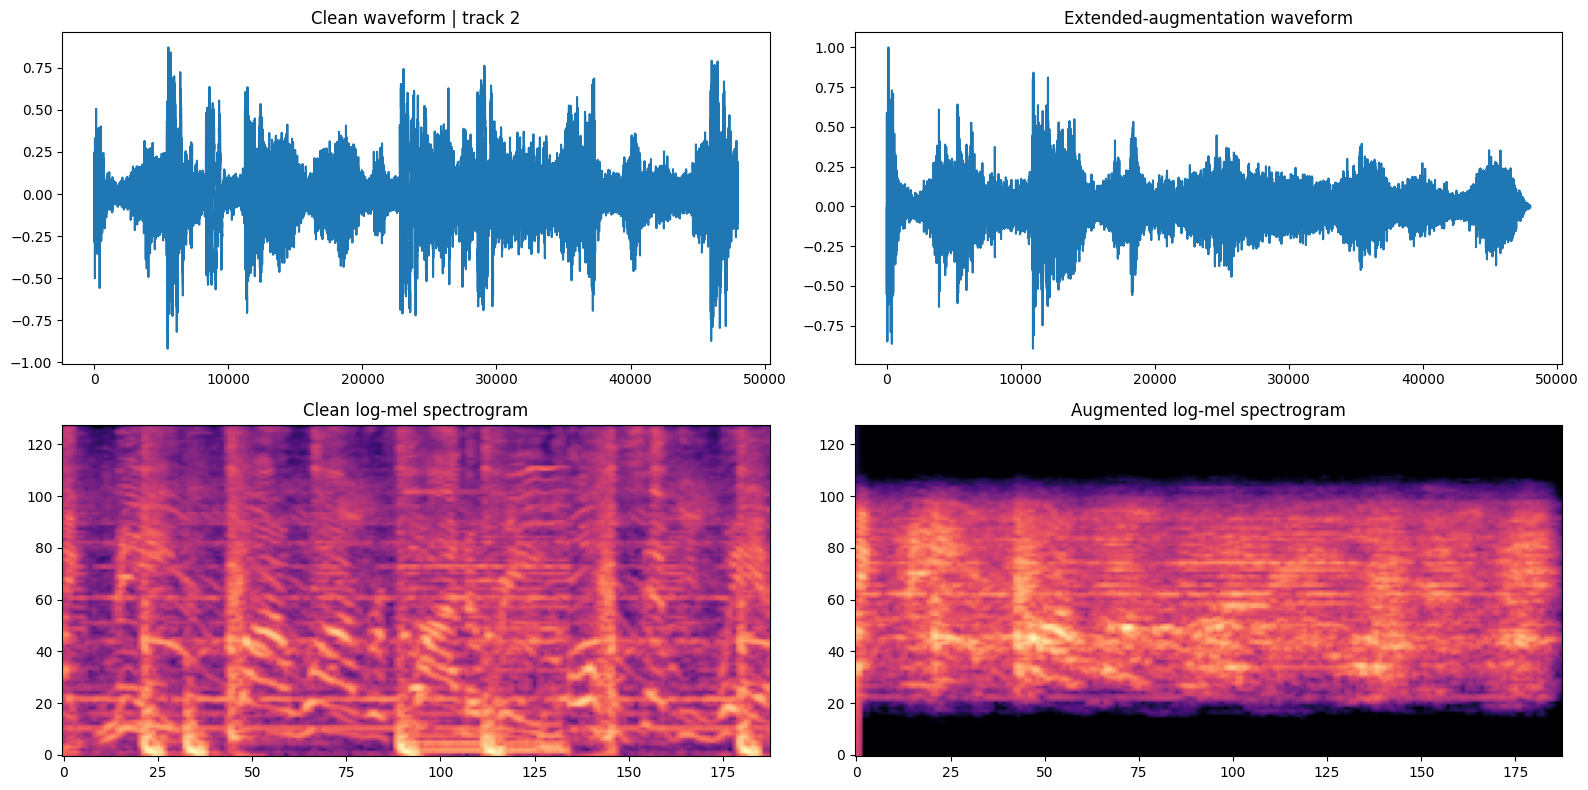

In [32]:
# Augmentation helpers and visualization.
def add_gaussian_noise(waveform: np.ndarray, rng: np.random.Generator, snr_db: float) -> np.ndarray:
    """Add Gaussian noise at a specified signal-to-noise ratio."""
    if snr_db <= 0:
        raise ValueError(f"snr_db must be positive, received {snr_db}.")
    signal_power = float(np.mean(np.square(waveform)))
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))
    noise = rng.normal(0.0, np.sqrt(noise_power), size=waveform.shape[0]).astype(np.float32)
    return (waveform + noise).astype(np.float32)


def apply_random_gain(waveform: np.ndarray, rng: np.random.Generator, min_db: float, max_db: float) -> np.ndarray:
    """Apply a random volume change in decibels."""
    if min_db > max_db:
        raise ValueError("min_db must be <= max_db.")
    gain_db = float(rng.uniform(min_db, max_db))
    gain = 10.0 ** (gain_db / 20.0)
    return (waveform * gain).astype(np.float32)


def apply_time_stretch(waveform: np.ndarray, rate: float) -> np.ndarray:
    """Time-stretch a waveform without changing pitch."""
    if rate <= 0:
        raise ValueError(f"rate must be positive, received {rate}.")
    return librosa.effects.time_stretch(waveform, rate=rate).astype(np.float32)


def apply_pitch_shift(waveform: np.ndarray, sample_rate: int, n_steps: float) -> np.ndarray:
    """Pitch-shift a waveform by the requested number of semitones."""
    return librosa.effects.pitch_shift(waveform, sr=sample_rate, n_steps=n_steps).astype(np.float32)


def apply_lowpass_filter(waveform: np.ndarray, sample_rate: int, cutoff_hz: float, order: int = 5) -> np.ndarray:
    """Apply a Butterworth low-pass filter."""
    nyquist = sample_rate / 2.0
    if cutoff_hz <= 0 or cutoff_hz >= nyquist:
        raise ValueError(f"cutoff_hz must be in (0, {nyquist}), received {cutoff_hz}.")
    b, a = scipy.signal.butter(order, cutoff_hz / nyquist, btype="low")
    return scipy.signal.filtfilt(b, a, waveform).astype(np.float32)


def apply_highpass_filter(waveform: np.ndarray, sample_rate: int, cutoff_hz: float, order: int = 5) -> np.ndarray:
    """Apply a Butterworth high-pass filter."""
    nyquist = sample_rate / 2.0
    if cutoff_hz <= 0 or cutoff_hz >= nyquist:
        raise ValueError(f"cutoff_hz must be in (0, {nyquist}), received {cutoff_hz}.")
    b, a = scipy.signal.butter(order, cutoff_hz / nyquist, btype="high")
    return scipy.signal.filtfilt(b, a, waveform).astype(np.float32)


def apply_augmentation_profile(
    waveform: np.ndarray,
    sample_rate: int,
    target_length: int,
    profile: AugmentationProfileName,
    rng: np.random.Generator,
) -> np.ndarray:
    """Apply the selected augmentation profile to a waveform segment."""
    segment = trim_or_pad_waveform(normalize_waveform(waveform), target_length)
    segment = trim_or_pad_waveform(apply_random_gain(segment, rng=rng, min_db=-6.0, max_db=6.0), target_length)
    segment = trim_or_pad_waveform(add_gaussian_noise(segment, rng=rng, snr_db=float(rng.uniform(10.0, 25.0))), target_length)
    segment = trim_or_pad_waveform(apply_time_stretch(segment, rate=float(rng.uniform(0.92, 1.08))), target_length)
    segment = trim_or_pad_waveform(apply_pitch_shift(segment, sample_rate=sample_rate, n_steps=float(rng.uniform(-2.0, 2.0))), target_length)

    if profile == "extended":
        segment = trim_or_pad_waveform(
            apply_lowpass_filter(segment, sample_rate=sample_rate, cutoff_hz=float(rng.uniform(2500.0, 5000.0))),
            target_length,
        )
        segment = trim_or_pad_waveform(
            apply_highpass_filter(segment, sample_rate=sample_rate, cutoff_hz=float(rng.uniform(120.0, 900.0))),
            target_length,
        )

    return normalize_waveform(segment)


def apply_retrieval_degradation(
    waveform: np.ndarray,
    sample_rate: int,
    target_length: int,
    condition: RetrievalConditionName,
    rng: np.random.Generator,
) -> np.ndarray:
    """Apply a deterministic query degradation for retrieval evaluation."""
    segment = trim_or_pad_waveform(normalize_waveform(waveform), target_length)
    if condition == "clean":
        return segment
    if condition == "noise":
        return trim_or_pad_waveform(add_gaussian_noise(segment, rng=rng, snr_db=8.0), target_length)
    if condition == "pitch":
        return trim_or_pad_waveform(apply_pitch_shift(segment, sample_rate=sample_rate, n_steps=2.0), target_length)
    if condition == "time":
        return trim_or_pad_waveform(apply_time_stretch(segment, rate=1.10), target_length)
    if condition == "lowpass":
        return trim_or_pad_waveform(apply_lowpass_filter(segment, sample_rate=sample_rate, cutoff_hz=3000.0), target_length)
    if condition == "highpass":
        return trim_or_pad_waveform(apply_highpass_filter(segment, sample_rate=sample_rate, cutoff_hz=500.0), target_length)
    raise ValueError(f"Unsupported retrieval condition: {condition}")


def visualize_preprocessing_example(config: ExperimentConfig, tracks_subset: pd.DataFrame) -> None:
    """Plot one clean segment and one extended-augmentation segment for sanity checking."""
    example_track_id = int(tracks_subset.index[0])
    waveform, _ = load_audio_file(get_audio_path(config.paths.audio_dir, example_track_id), target_sr=config.sample_rate)
    clean_segment, _ = extract_center_segment(waveform, config.segment_samples)
    augmented_segment = apply_augmentation_profile(
        waveform=clean_segment,
        sample_rate=config.sample_rate,
        target_length=config.segment_samples,
        profile="extended",
        rng=np.random.default_rng(config.seed),
    )
    clean_spec = compute_log_mel_spectrogram(clean_segment, config.sample_rate, config.n_fft, config.hop_length, config.n_mels)
    augmented_spec = compute_log_mel_spectrogram(augmented_segment, config.sample_rate, config.n_fft, config.hop_length, config.n_mels)

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes[0, 0].plot(clean_segment)
    axes[0, 0].set_title(f"Clean waveform | track {example_track_id}")
    axes[0, 1].plot(augmented_segment)
    axes[0, 1].set_title("Extended-augmentation waveform")
    axes[1, 0].imshow(clean_spec, origin="lower", aspect="auto", cmap="magma")
    axes[1, 0].set_title("Clean log-mel spectrogram")
    axes[1, 1].imshow(augmented_spec, origin="lower", aspect="auto", cmap="magma")
    axes[1, 1].set_title("Augmented log-mel spectrogram")
    plt.tight_layout()
    plt.show()


visualize_preprocessing_example(CONFIG, tracks_small)


## Datasets And Loaders

The training set yields anchor and positive pairs for contrastive learning. Retrieval datasets produce one deterministic reference or query segment per track. Spectrogram models receive `(1, n_mels, time_frames)` tensors, while MERT receives raw waveforms and uses a custom collate function built around `Wav2Vec2FeatureExtractor`.

In [33]:
# Dataset classes, collate functions, and split helpers.
class PairBatch(TypedDict):
    anchor: torch.Tensor
    positive: torch.Tensor
    track_id: torch.Tensor
    anchor_start_time: torch.Tensor


class RetrievalBatch(TypedDict):
    inputs: torch.Tensor
    track_id: torch.Tensor


def seed_worker(worker_id: int) -> None:
    """Seed NumPy and Python RNGs inside a DataLoader worker."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_torch_generator(seed: int) -> torch.Generator:
    """Build a deterministic PyTorch generator for DataLoader shuffling."""
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


class ContrastivePairDataset(Dataset[dict[str, object]]):
    """Yield anchor and positive pairs for contrastive training."""

    def __init__(
        self,
        audio_dir: Path,
        track_ids: list[int],
        segment_length: int,
        sample_rate: int,
        input_mode: InputMode,
        config: ExperimentConfig,
        augmentation_profile: AugmentationProfileName,
    ) -> None:
        self.audio_dir = audio_dir
        self.track_ids = track_ids
        self.segment_length = segment_length
        self.sample_rate = sample_rate
        self.input_mode = input_mode
        self.config = config
        self.augmentation_profile = augmentation_profile

    def __len__(self) -> int:
        return len(self.track_ids)

    def __getitem__(self, index: int) -> dict[str, object]:
        track_id = self.track_ids[index]
        seed = int(torch.randint(low=0, high=2**31 - 1, size=(1,)).item())
        rng = np.random.default_rng(seed)
        waveform, _ = load_audio_file(get_audio_path(self.audio_dir, track_id), target_sr=self.sample_rate)
        segment, start_index = extract_random_segment(waveform, self.segment_length, rng=rng)
        segment = normalize_waveform(trim_or_pad_waveform(segment, self.segment_length))
        positive_waveform = apply_augmentation_profile(
            waveform=segment.copy(),
            sample_rate=self.sample_rate,
            target_length=self.segment_length,
            profile=self.augmentation_profile,
            rng=rng,
        )

        if self.input_mode == "spectrogram":
            anchor_value: torch.Tensor = spectrogram_tensor_from_waveform(segment, self.config)
            positive_value: torch.Tensor = spectrogram_tensor_from_waveform(positive_waveform, self.config)
        else:
            anchor_value = torch.from_numpy(segment).float()
            positive_value = torch.from_numpy(positive_waveform).float()

        return {
            "anchor": anchor_value,
            "positive": positive_value,
            "track_id": int(track_id),
            "anchor_start_time": float(start_index / self.sample_rate),
        }


class RetrievalReferenceDataset(Dataset[dict[str, object]]):
    """Yield deterministic reference segments for FAISS indexing."""

    def __init__(
        self,
        audio_dir: Path,
        track_ids: list[int],
        segment_length: int,
        sample_rate: int,
        input_mode: InputMode,
        config: ExperimentConfig,
    ) -> None:
        self.audio_dir = audio_dir
        self.track_ids = track_ids
        self.segment_length = segment_length
        self.sample_rate = sample_rate
        self.input_mode = input_mode
        self.config = config

    def __len__(self) -> int:
        return len(self.track_ids)

    def __getitem__(self, index: int) -> dict[str, object]:
        track_id = self.track_ids[index]
        waveform, _ = load_audio_file(get_audio_path(self.audio_dir, track_id), target_sr=self.sample_rate)
        segment, _ = extract_center_segment(waveform, self.segment_length)
        if self.input_mode == "spectrogram":
            model_input: torch.Tensor = spectrogram_tensor_from_waveform(segment, self.config)
        else:
            model_input = torch.from_numpy(segment).float()
        return {"inputs": model_input, "track_id": int(track_id)}


class RetrievalQueryDataset(Dataset[dict[str, object]]):
    """Yield deterministic degraded query segments for retrieval evaluation."""

    def __init__(
        self,
        audio_dir: Path,
        track_ids: list[int],
        segment_length: int,
        sample_rate: int,
        input_mode: InputMode,
        config: ExperimentConfig,
        condition: RetrievalConditionName,
    ) -> None:
        self.audio_dir = audio_dir
        self.track_ids = track_ids
        self.segment_length = segment_length
        self.sample_rate = sample_rate
        self.input_mode = input_mode
        self.config = config
        self.condition = condition

    def __len__(self) -> int:
        return len(self.track_ids)

    def __getitem__(self, index: int) -> dict[str, object]:
        track_id = self.track_ids[index]
        rng = np.random.default_rng(self.config.seed + index)
        waveform, _ = load_audio_file(get_audio_path(self.audio_dir, track_id), target_sr=self.sample_rate)
        segment, _ = extract_center_segment(waveform, self.segment_length)
        degraded = apply_retrieval_degradation(
            waveform=segment,
            sample_rate=self.sample_rate,
            target_length=self.segment_length,
            condition=self.condition,
            rng=rng,
        )
        if self.input_mode == "spectrogram":
            model_input: torch.Tensor = spectrogram_tensor_from_waveform(degraded, self.config)
        else:
            model_input = torch.from_numpy(degraded).float()
        return {"inputs": model_input, "track_id": int(track_id)}


def collate_pair_batch(batch: list[dict[str, object]]) -> PairBatch:
    """Stack spectrogram or waveform pair samples into one batch."""
    anchors = torch.stack([sample["anchor"] for sample in batch])
    positives = torch.stack([sample["positive"] for sample in batch])
    track_ids = torch.tensor([int(sample["track_id"]) for sample in batch], dtype=torch.long)
    start_times = torch.tensor([float(sample["anchor_start_time"]) for sample in batch], dtype=torch.float32)
    return {
        "anchor": anchors,
        "positive": positives,
        "track_id": track_ids,
        "anchor_start_time": start_times,
    }


def collate_retrieval_batch(batch: list[dict[str, object]]) -> RetrievalBatch:
    """Stack spectrogram or waveform retrieval samples into one batch."""
    inputs = torch.stack([sample["inputs"] for sample in batch])
    track_ids = torch.tensor([int(sample["track_id"]) for sample in batch], dtype=torch.long)
    return {"inputs": inputs, "track_id": track_ids}


def build_mert_pair_collate_fn(feature_extractor: Wav2Vec2FeatureExtractor) -> Callable[[list[dict[str, object]]], dict[str, torch.Tensor]]:
    """Build the MERT pair collate function."""

    def collate(batch: list[dict[str, object]]) -> dict[str, torch.Tensor]:
        anchor_arrays = [np.asarray(sample["anchor"], dtype=np.float32) for sample in batch]
        positive_arrays = [np.asarray(sample["positive"], dtype=np.float32) for sample in batch]
        anchor_inputs = feature_extractor(anchor_arrays, sampling_rate=feature_extractor.sampling_rate, return_tensors="pt", padding=True)
        positive_inputs = feature_extractor(positive_arrays, sampling_rate=feature_extractor.sampling_rate, return_tensors="pt", padding=True)
        return {
            "anchor_input_values": anchor_inputs["input_values"],
            "anchor_attention_mask": anchor_inputs["attention_mask"],
            "positive_input_values": positive_inputs["input_values"],
            "positive_attention_mask": positive_inputs["attention_mask"],
            "track_id": torch.tensor([int(sample["track_id"]) for sample in batch], dtype=torch.long),
            "anchor_start_time": torch.tensor([float(sample["anchor_start_time"]) for sample in batch], dtype=torch.float32),
        }

    return collate


def build_mert_retrieval_collate_fn(feature_extractor: Wav2Vec2FeatureExtractor) -> Callable[[list[dict[str, object]]], dict[str, torch.Tensor]]:
    """Build the MERT retrieval collate function."""

    def collate(batch: list[dict[str, object]]) -> dict[str, torch.Tensor]:
        waveform_arrays = [np.asarray(sample["inputs"], dtype=np.float32) for sample in batch]
        feature_batch = feature_extractor(waveform_arrays, sampling_rate=feature_extractor.sampling_rate, return_tensors="pt", padding=True)
        return {
            "inputs": feature_batch["input_values"],
            "attention_mask": feature_batch["attention_mask"],
            "track_id": torch.tensor([int(sample["track_id"]) for sample in batch], dtype=torch.long),
        }

    return collate


def get_split_track_ids(
    subset_tracks: pd.DataFrame,
    max_train_tracks: int | None = None,
    max_eval_tracks: int | None = None,
) -> dict[str, list[int]]:
    """Collect track IDs for the training, validation, and test splits."""
    training_ids = [int(track_id) for track_id in subset_tracks[subset_tracks["set", "split"] == "training"].index.tolist()]
    validation_ids = [int(track_id) for track_id in subset_tracks[subset_tracks["set", "split"] == "validation"].index.tolist()]
    test_ids = [int(track_id) for track_id in subset_tracks[subset_tracks["set", "split"] == "test"].index.tolist()]

    if max_train_tracks is not None:
        training_ids = training_ids[:max_train_tracks]
    if max_eval_tracks is not None:
        validation_ids = validation_ids[:max_eval_tracks]
        test_ids = test_ids[:max_eval_tracks]

    return {
        "training": training_ids,
        "validation": validation_ids,
        "test": test_ids,
    }


SPLIT_TRACK_IDS = get_split_track_ids(
    tracks_small,
    max_train_tracks=CONFIG.max_train_tracks,
    max_eval_tracks=CONFIG.max_eval_tracks,
)
{split_name: len(track_ids) for split_name, track_ids in SPLIT_TRACK_IDS.items()}


{'training': 6397, 'validation': 800, 'test': 800}

## Minimal Baseline: Loss And Models

This section defines the shared NT-Xent loss, the compact CNN baseline, the hybrid spectrogram transformer, and the frozen MERT fingerprinter. All three models emit L2-normalized embeddings so FAISS can use exact inner-product search as cosine-equivalent retrieval.

In [34]:
# Loss and model definitions.
class NTXentLoss(nn.Module):
    """Symmetric NT-Xent loss for contrastive representation learning."""

    def __init__(self, temperature: float) -> None:
        super().__init__()
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        self.temperature = temperature

    def forward(self, anchor_embeddings: torch.Tensor, positive_embeddings: torch.Tensor) -> torch.Tensor:
        batch_size = anchor_embeddings.shape[0]
        if batch_size < 2:
            raise ValueError("NT-Xent requires a batch size of at least 2.")
        anchor_embeddings = F.normalize(anchor_embeddings, p=2, dim=1)
        positive_embeddings = F.normalize(positive_embeddings, p=2, dim=1)
        logits = anchor_embeddings @ positive_embeddings.T / self.temperature
        labels = torch.arange(batch_size, device=logits.device)
        loss_anchor = F.cross_entropy(logits, labels)
        loss_positive = F.cross_entropy(logits.T, labels)
        return 0.5 * (loss_anchor + loss_positive)


class ProjectionHead(nn.Module):
    """Two-layer projection head used by every fingerprinting model."""

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(p=0.1),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        embeddings = self.layers(inputs)
        return F.normalize(embeddings, p=2, dim=1)


class ConvBlock(nn.Module):
    """A simple convolution, normalization, and activation block."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.block(inputs)


class CompactSpectrogramCNN(nn.Module):
    """Compact spectrogram CNN baseline for contrastive fingerprinting."""

    def __init__(self, embed_dim: int, projection_hidden_dim: int) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1, 32, stride=2),
            ConvBlock(32, 64, stride=2),
            ConvBlock(64, 128, stride=2),
            ConvBlock(128, 256, stride=2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.projection = ProjectionHead(256, projection_hidden_dim, embed_dim)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.encoder(inputs)
        pooled = self.pool(features).flatten(start_dim=1)
        return self.projection(pooled)


class TransformerEncoderStack(nn.Module):
    """A small Transformer encoder with optional activation checkpointing."""

    def __init__(self, d_model: int, num_heads: int, num_layers: int, dropout: float, use_gradient_checkpointing: bool) -> None:
        super().__init__()
        self.layers = nn.ModuleList(
            [
                nn.TransformerEncoderLayer(
                    d_model=d_model,
                    nhead=num_heads,
                    dim_feedforward=d_model * 4,
                    dropout=dropout,
                    activation="gelu",
                    batch_first=True,
                    norm_first=True,
                )
                for _ in range(num_layers)
            ]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.use_gradient_checkpointing = use_gradient_checkpointing

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        hidden_states = inputs
        for layer in self.layers:
            if self.use_gradient_checkpointing and self.training:
                hidden_states = checkpoint(lambda tensor: layer(tensor), hidden_states, use_reentrant=False)
            else:
                hidden_states = layer(hidden_states)
        return self.final_norm(hidden_states)


class HybridSpectrogramTransformer(nn.Module):
    """Hybrid spectrogram transformer used as the main scratch model."""

    def __init__(self, config: ExperimentConfig, embed_dim: int) -> None:
        super().__init__()
        self.config = config
        self.conv_stem = nn.Sequential(
            ConvBlock(1, 64, stride=2),
            ConvBlock(64, 128, stride=2),
        )
        self.patch_projection = nn.Conv2d(128, 256, kernel_size=4, stride=4)
        self.encoder = TransformerEncoderStack(256, 4, 4, 0.1, config.gradient_checkpointing)
        token_count = self._compute_token_count(config.n_mels, config.spectrogram_frames)
        self.position_embeddings = nn.Parameter(torch.zeros(1, token_count, 256))
        nn.init.trunc_normal_(self.position_embeddings, std=0.02)
        self.projection = ProjectionHead(256, config.projection_hidden_dim, embed_dim)

    @staticmethod
    def _compute_token_count(input_height: int, input_width: int) -> int:
        """Compute token count after the conv stem and patch projection."""
        height_after_stem = (input_height + 1) // 2
        height_after_stem = (height_after_stem + 1) // 2
        width_after_stem = (input_width + 1) // 2
        width_after_stem = (width_after_stem + 1) // 2
        height_after_patch = ((height_after_stem - 4) // 4) + 1
        width_after_patch = ((width_after_stem - 4) // 4) + 1
        return height_after_patch * width_after_patch

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        hidden = self.conv_stem(inputs)
        hidden = self.patch_projection(hidden)
        tokens = hidden.flatten(start_dim=2).transpose(1, 2)
        tokens = tokens + self.position_embeddings[:, : tokens.shape[1], :]
        encoded = self.encoder(tokens)
        pooled = encoded.mean(dim=1)
        return self.projection(pooled)


class FrozenMertFingerprinter(nn.Module):
    """Frozen MERT backbone with a trainable projection head."""

    def __init__(self, model_name: str, embed_dim: int, projection_hidden_dim: int, freeze_backbone: bool = True, weighted_layer_pooling: bool = False) -> None:
        super().__init__()
        self.model_name = model_name
        self.freeze_backbone = freeze_backbone
        self.weighted_layer_pooling = weighted_layer_pooling
        self.feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.hidden_size = int(self.backbone.config.hidden_size)
        self.projection = ProjectionHead(self.hidden_size, projection_hidden_dim, embed_dim)

        if self.weighted_layer_pooling:
            layer_count = int(self.backbone.config.num_hidden_layers) + 1
            self.layer_weights = nn.Parameter(torch.ones(layer_count) / layer_count)
        else:
            self.layer_weights = None

        if self.freeze_backbone:
            for parameter in self.backbone.parameters():
                parameter.requires_grad = False
            self.backbone.eval()

    @property
    def sample_rate(self) -> int:
        return int(self.feature_extractor.sampling_rate)

    def train(self, mode: bool = True) -> "FrozenMertFingerprinter":
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()
        return self

    def _pool_hidden_states(self, outputs: object, attention_mask: torch.Tensor | None) -> torch.Tensor:
        """Pool hidden states with attention-mask awareness.

        For MERT/Hubert-style backbones, the raw waveform attention mask is longer
        than the encoder sequence length because the convolutional feature extractor
        downsamples the time axis. In that case, reduce the mask to feature-vector
        length before masked pooling.
        """
        if self.weighted_layer_pooling:
            hidden_states = getattr(outputs, "hidden_states")
            stacked_hidden_states = torch.stack(list(hidden_states), dim=0)
            normalized_weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
            sequence_output = torch.sum(normalized_weights * stacked_hidden_states, dim=0)
        else:
            sequence_output = getattr(outputs, "last_hidden_state")

        if attention_mask is None:
            return sequence_output.mean(dim=1)

        if attention_mask.shape[1] != sequence_output.shape[1]:
            if not hasattr(self.backbone, "_get_feature_vector_attention_mask"):
                raise RuntimeError(
                    "Attention-mask length does not match hidden-state sequence length "
                    f"({attention_mask.shape[1]} vs {sequence_output.shape[1]}), and the "
                  "backbone does not expose _get_feature_vector_attention_mask()."
                )

            attention_mask = self.backbone._get_feature_vector_attention_mask(
                sequence_output.shape[1],
                attention_mask,
            )

        mask = attention_mask.unsqueeze(-1).to(sequence_output.dtype)
        masked_sum = torch.sum(sequence_output * mask, dim=1)
        mask_sum = torch.clamp(mask.sum(dim=1), min=1.0)
        return masked_sum / mask_sum

    def forward(self, input_values: torch.Tensor, attention_mask: torch.Tensor | None = None) -> torch.Tensor:
        backbone_kwargs = {
            "input_values": input_values,
            "attention_mask": attention_mask,
            "output_hidden_states": self.weighted_layer_pooling,
        }
        if self.freeze_backbone:
            with torch.no_grad():
                outputs = self.backbone(**backbone_kwargs)
        else:
            outputs = self.backbone(**backbone_kwargs)
        pooled = self._pool_hidden_states(outputs, attention_mask=attention_mask)
        return self.projection(pooled)


## Training, Retrieval, And Artifacts

The fixed execution order is:
1. dataset and model smoke tests
2. CNN baseline
3. hybrid transformer with baseline augmentation
4. hybrid transformer with extended augmentation
5. hybrid transformer with extended augmentation and a larger embedding
6. frozen MERT baseline

Exact retrieval uses `faiss.IndexFlatIP` over L2-normalized embeddings stored as `float32`.

In [35]:
# Training, retrieval, and plotting helpers.
def serialize_jsonable(value: object) -> object:
    """Recursively convert dataclasses and paths into JSON-safe values."""
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, tuple):
        return [serialize_jsonable(item) for item in value]
    if isinstance(value, list):
        return [serialize_jsonable(item) for item in value]
    if isinstance(value, dict):
        return {str(key): serialize_jsonable(item) for key, item in value.items()}
    if hasattr(value, "__dataclass_fields__"):
        return {field_name: serialize_jsonable(getattr(value, field_name)) for field_name in value.__dataclass_fields__.keys()}
    return value


def make_run_directory(config: ExperimentConfig, run_config: ModelRunConfig) -> Path:
    """Create the output directory for a single run."""
    run_dir = config.paths.output_root / run_config.run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


def clear_memory() -> None:
    """Release cached Python and CUDA memory between runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def build_model(config: ExperimentConfig, run_config: ModelRunConfig) -> tuple[nn.Module, InputMode, int, Callable[[list[dict[str, object]]], dict[str, torch.Tensor]] | None]:
    """Instantiate a model and return its input mode and optional collate function."""
    if run_config.model_name == "cnn":
        model = CompactSpectrogramCNN(run_config.embed_dim, config.projection_hidden_dim)
        return model, "spectrogram", config.sample_rate, None

    if run_config.model_name == "hybrid_transformer":
        model = HybridSpectrogramTransformer(config, run_config.embed_dim)
        return model, "spectrogram", config.sample_rate, None

    model = FrozenMertFingerprinter("m-a-p/MERT-v1-95M", run_config.embed_dim, config.projection_hidden_dim, run_config.freeze_backbone, False)
    return model, "mert_waveform", model.sample_rate, build_mert_pair_collate_fn(model.feature_extractor)


def build_retrieval_collate_fn(model: nn.Module, input_mode: InputMode) -> Callable[[list[dict[str, object]]], dict[str, torch.Tensor]]:
    """Return the retrieval collate function for a model family."""
    if input_mode == "spectrogram":
        return collate_retrieval_batch
    if not isinstance(model, FrozenMertFingerprinter):
        raise TypeError("MERT retrieval collate requires a FrozenMertFingerprinter instance.")
    return build_mert_retrieval_collate_fn(model.feature_extractor)


def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    """Move all tensor values in a batch dictionary to the requested device."""
    return {key: value.to(device) if isinstance(value, torch.Tensor) else value for key, value in batch.items()}


def forward_pair_batch(model: nn.Module, batch: dict[str, torch.Tensor], input_mode: InputMode, device_type: str, amp_enabled: bool) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute anchor and positive embeddings for one training batch."""
    with torch.amp.autocast(device_type=device_type, enabled=amp_enabled):
        if input_mode == "spectrogram":
            anchor_embeddings = model(batch["anchor"])
            positive_embeddings = model(batch["positive"])
        else:
            if not isinstance(model, FrozenMertFingerprinter):
                raise TypeError("Waveform batches require FrozenMertFingerprinter.")
            anchor_embeddings = model(batch["anchor_input_values"], batch["anchor_attention_mask"])
            positive_embeddings = model(batch["positive_input_values"], batch["positive_attention_mask"])
    return anchor_embeddings, positive_embeddings


def encode_retrieval_batch(model: nn.Module, batch: dict[str, torch.Tensor], input_mode: InputMode, device: torch.device, device_type: str, amp_enabled: bool) -> torch.Tensor:
    """Encode one retrieval batch into embeddings."""
    with torch.no_grad():
        with torch.amp.autocast(device_type=device_type, enabled=amp_enabled):
            if input_mode == "spectrogram":
                return model(batch["inputs"].to(device))
            if not isinstance(model, FrozenMertFingerprinter):
                raise TypeError("Waveform retrieval batches require FrozenMertFingerprinter.")
            return model(batch["inputs"].to(device), batch["attention_mask"].to(device))


def train_one_epoch(model: nn.Module, loader: DataLoader[dict[str, torch.Tensor]], optimizer: torch.optim.Optimizer, loss_fn: NTXentLoss, device: torch.device, input_mode: InputMode, config: ExperimentConfig) -> float:
    """Train a model for one epoch and return the mean loss."""
    model.train()
    if isinstance(model, FrozenMertFingerprinter) and model.freeze_backbone:
        model.backbone.eval()
    scaler = torch.amp.GradScaler(config.device_type, enabled=config.amp_enabled)
    epoch_losses: list[float] = []

    for batch in tqdm(loader, desc="train", leave=False):
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        anchor_embeddings, positive_embeddings = forward_pair_batch(model, batch, input_mode, config.device_type, config.amp_enabled)
        loss = loss_fn(anchor_embeddings, positive_embeddings)
        if not torch.isfinite(loss):
            raise FloatingPointError("Encountered a non-finite training loss.")
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.gradient_clip_norm)
        scaler.step(optimizer)
        scaler.update()
        epoch_losses.append(float(loss.detach().cpu().item()))

    return float(np.mean(epoch_losses))


def validate_epoch(model: nn.Module, loader: DataLoader[dict[str, torch.Tensor]], loss_fn: NTXentLoss, device: torch.device, input_mode: InputMode, config: ExperimentConfig) -> float:
    """Evaluate mean contrastive loss on the validation loader."""
    model.eval()
    losses: list[float] = []
    for batch in tqdm(loader, desc="validate", leave=False):
        batch = move_batch_to_device(batch, device)
        anchor_embeddings, positive_embeddings = forward_pair_batch(model, batch, input_mode, config.device_type, config.amp_enabled)
        loss = loss_fn(anchor_embeddings, positive_embeddings)
        losses.append(float(loss.detach().cpu().item()))
    return float(np.mean(losses))


In [ ]:
# Embedding extraction, retrieval metrics, and artifact writers.
def extract_embeddings(model: nn.Module, loader: DataLoader[dict[str, torch.Tensor]], input_mode: InputMode, device: torch.device, config: ExperimentConfig) -> tuple[np.ndarray, np.ndarray]:
    """Encode a loader into a NumPy embedding matrix and aligned track IDs."""
    model.eval()
    embedding_chunks: list[np.ndarray] = []
    track_id_chunks: list[np.ndarray] = []
    for batch in tqdm(loader, desc="embed", leave=False):
        track_ids = batch["track_id"].detach().cpu().numpy().astype(np.int64)
        encoded = encode_retrieval_batch(model, batch, input_mode, device, config.device_type, config.amp_enabled)
        embedding_chunks.append(encoded.detach().cpu().numpy().astype(np.float32))
        track_id_chunks.append(track_ids)
    return np.concatenate(embedding_chunks, axis=0), np.concatenate(track_id_chunks, axis=0)


def build_faiss_index(reference_embeddings: np.ndarray) -> faiss.IndexFlatIP:
    """Build an exact FAISS index over L2-normalized float32 embeddings."""
    if reference_embeddings.dtype != np.float32:
        reference_embeddings = reference_embeddings.astype(np.float32)
    faiss.normalize_L2(reference_embeddings)
    index = faiss.IndexFlatIP(reference_embeddings.shape[1])
    index.add(reference_embeddings)
    return index


def compute_rank_metrics(ranked_reference_ids: np.ndarray, query_track_ids: np.ndarray, top_k: tuple[int, ...]) -> dict[str, float]:
    """Compute Top-k accuracy and MRR from ranked reference IDs."""
    metrics: dict[str, float] = {}
    reciprocal_ranks: list[float] = []
    for query_index, query_track_id in enumerate(query_track_ids):
        ranked_ids = ranked_reference_ids[query_index]
        match_indices = np.where(ranked_ids == query_track_id)[0]
        rank = int(match_indices[0]) + 1 if match_indices.size else ranked_ids.shape[0] + 1
        reciprocal_ranks.append(1.0 / rank)
        for k in top_k:
            metrics.setdefault(f"top{k}", 0.0)
            metrics[f"top{k}"] += 1.0 if rank <= k else 0.0

    query_count = float(len(query_track_ids))
    for k in top_k:
        metrics[f"top{k}"] /= query_count
    metrics["mrr"] = float(np.mean(reciprocal_ranks))
    return metrics


def evaluate_retrieval(
    model: nn.Module,
    reference_loader: DataLoader[dict[str, torch.Tensor]],
    query_loaders: dict[RetrievalConditionName, DataLoader[dict[str, torch.Tensor]]],
    input_mode: InputMode,
    device: torch.device,
    config: ExperimentConfig,
    run_dir: Path,
) -> tuple[dict[str, float], pd.DataFrame]:
    """Build a FAISS index, save retrieval artifacts, and evaluate clean plus degraded retrieval metrics."""
    run_dir.mkdir(parents=True, exist_ok=True)

    reference_embeddings, reference_track_ids = extract_embeddings(
        model,
        reference_loader,
        input_mode,
        device,
        config,
    )
    np.save(run_dir / "reference_embeddings.npy", reference_embeddings.astype(np.float32))
    np.save(run_dir / "reference_track_ids.npy", reference_track_ids.astype(np.int64))

    index = build_faiss_index(reference_embeddings.copy())
    faiss.write_index(index, str(run_dir / "reference_index.faiss"))

    results: dict[str, float] = {}
    degradation_rows: list[dict[str, object]] = []

    for condition, query_loader in query_loaders.items():
        query_embeddings, query_track_ids = extract_embeddings(
            model,
            query_loader,
            input_mode,
            device,
            config,
        )
        np.save(run_dir / f"query_embeddings_{condition}.npy", query_embeddings.astype(np.float32))
        np.save(run_dir / f"query_track_ids_{condition}.npy", query_track_ids.astype(np.int64))

        normalized_query_embeddings = query_embeddings.astype(np.float32).copy()
        faiss.normalize_L2(normalized_query_embeddings)

        _, neighbor_indices = index.search(normalized_query_embeddings, max(config.top_k))
        ranked_reference_ids = reference_track_ids[neighbor_indices]
        condition_metrics = compute_rank_metrics(ranked_reference_ids, query_track_ids, config.top_k)

        degradation_rows.append(
            {
                "condition": condition,
                "top1": condition_metrics["top1"],
                "top5": condition_metrics["top5"],
                "top10": condition_metrics["top10"],
                "mrr": condition_metrics["mrr"],
            }
        )

        if condition == "clean":
            results["clean_top1"] = condition_metrics["top1"]
            results["clean_top5"] = condition_metrics["top5"]
            results["clean_top10"] = condition_metrics["top10"]
            results["clean_mrr"] = condition_metrics["mrr"]
        else:
            results[f"{condition}_top1"] = condition_metrics["top1"]

    return results, pd.DataFrame(degradation_rows)


def save_json(filepath: Path, payload: object) -> None:
    """Write a JSON artifact with stable indentation."""
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with filepath.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
        handle.write("\n")


def plot_training_history(history: list[dict[str, float]], output_path: Path, run_title: str) -> None:
    """Save a compact loss-curve plot for one experiment run."""
    epochs = [int(item["epoch"]) for item in history]
    train_losses = [float(item["train_loss"]) for item in history]
    val_losses = [float(item["val_loss"]) for item in history]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, train_losses, marker="o", label="Train loss")
    ax.plot(epochs, val_losses, marker="s", label="Validation loss")
    ax.set_title(f"Loss curves | {run_title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("NT-Xent loss")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)


def plot_retrieval_bars(degradation_df: pd.DataFrame, output_path: Path, run_title: str) -> None:
    """Save a degradation-specific Top-1 bar chart for one experiment run."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(degradation_df["condition"], degradation_df["top1"], color="steelblue")
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Top-1 accuracy")
    ax.set_title(f"Retrieval robustness | {run_title}")
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)

def persist_output_artifacts(paths: PathConfig, persistent_root: Path) -> dict[str, str]:
    """Copy the completed local artifact directory and its ZIP bundle to persistent storage."""
    if not paths.output_root.exists():
        raise FileNotFoundError(f"Local output directory does not exist: {paths.output_root}")

    persistent_root.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_dir = persistent_root / f"run_{timestamp}"
    if export_dir.exists():
        raise FileExistsError(f"Refusing to overwrite existing export directory: {export_dir}")

    export_dir.mkdir(parents=True, exist_ok=False)

    local_zip_path = paths.artifact_zip
    if not local_zip_path.exists():
        raise FileNotFoundError(
            f"Expected ZIP artifact does not exist yet: {local_zip_path}. "
            "Call zip_output_artifacts(paths) before persist_output_artifacts(paths, persistent_root)."
        )

    exported_output_dir = export_dir / paths.output_root.name
    shutil.copytree(paths.output_root, exported_output_dir)

    exported_zip_path = export_dir / local_zip_path.name
    shutil.copy2(local_zip_path, exported_zip_path)

    manifest = {
        "export_timestamp": timestamp,
        "local_output_root": str(paths.output_root),
        "local_zip_path": str(local_zip_path),
        "persistent_export_dir": str(export_dir),
        "persistent_output_dir": str(exported_output_dir),
        "persistent_zip_path": str(exported_zip_path),
    }
    with (export_dir / "export_manifest.json").open("w", encoding="utf-8") as handle:
        json.dump(manifest, handle, indent=2)
        handle.write("\n")

    return manifest

In [37]:
# Experiment runners and failure checks.
def make_pair_loader(dataset: ContrastivePairDataset, batch_size: int, shuffle: bool, collate_fn: Callable[[list[dict[str, object]]], dict[str, torch.Tensor]], seed: int, num_workers: int) -> DataLoader[dict[str, torch.Tensor]]:
    """Build a deterministic DataLoader for contrastive pair datasets."""
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=build_torch_generator(seed),
        collate_fn=collate_fn,
    )


def make_retrieval_loader(dataset: Dataset[dict[str, object]], batch_size: int, collate_fn: Callable[[list[dict[str, object]]], dict[str, torch.Tensor]], num_workers: int) -> DataLoader[dict[str, torch.Tensor]]:
    """Build a deterministic DataLoader for retrieval datasets."""
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=build_torch_generator(CONFIG.seed),
        collate_fn=collate_fn,
    )


def run_model_smoke_tests(config: ExperimentConfig, split_track_ids: dict[str, list[int]]) -> pd.DataFrame:
    """Run one forward and backward pass for each primary model family."""
    smoke_rows: list[dict[str, object]] = []
    smoke_track_ids = split_track_ids["training"][: config.smoke_test_track_count]

    for run_config in config.run_presets:
        if run_config.model_name == "hybrid_transformer" and (run_config.augmentation_profile == "extended" or run_config.embed_dim == 256):
            continue

        model, input_mode, sample_rate, pair_collate_override = build_model(config, run_config)
        model = model.to(config.device)
        collate_fn = pair_collate_override if pair_collate_override is not None else collate_pair_batch
        batch_size = config.mert_batch_size if input_mode == "mert_waveform" else min(config.batch_size, 4)
        dataset = ContrastivePairDataset(config.paths.audio_dir, smoke_track_ids, int(config.segment_seconds * sample_rate), sample_rate, input_mode, config, run_config.augmentation_profile)
        loader = make_pair_loader(dataset, batch_size, True, collate_fn, config.seed, 0)
        batch = next(iter(loader))
        batch = move_batch_to_device(batch, config.device)
        loss_fn = NTXentLoss(run_config.temperature)
        optimizer = torch.optim.AdamW([parameter for parameter in model.parameters() if parameter.requires_grad], lr=run_config.learning_rate, weight_decay=run_config.weight_decay)
        optimizer.zero_grad(set_to_none=True)
        anchor_embeddings, positive_embeddings = forward_pair_batch(model, batch, input_mode, config.device_type, config.amp_enabled)
        loss = loss_fn(anchor_embeddings, positive_embeddings)
        loss.backward()
        optimizer.step()
        smoke_rows.append(
            {
                "model_name": run_config.model_name,
                "input_mode": input_mode,
                "loss": float(loss.detach().cpu().item()),
                "anchor_shape": tuple(anchor_embeddings.shape),
                "positive_shape": tuple(positive_embeddings.shape),
                "embedding_norm_mean": float(anchor_embeddings.norm(dim=1).mean().detach().cpu().item()),
            }
        )
        clear_memory()

    return pd.DataFrame(smoke_rows)


def build_experiment_loaders(config: ExperimentConfig, run_config: ModelRunConfig, model: nn.Module, input_mode: InputMode, sample_rate: int, pair_collate_override: Callable[[list[dict[str, object]]], dict[str, torch.Tensor]] | None, split_track_ids: dict[str, list[int]]) -> tuple[DataLoader[dict[str, torch.Tensor]], DataLoader[dict[str, torch.Tensor]], DataLoader[dict[str, torch.Tensor]], dict[RetrievalConditionName, DataLoader[dict[str, torch.Tensor]]]]:
    """Build train, validation, reference, and query loaders for one experiment run."""
    pair_collate_fn = pair_collate_override if pair_collate_override is not None else collate_pair_batch
    retrieval_collate_fn = build_retrieval_collate_fn(model, input_mode)
    pair_batch_size = config.mert_batch_size if input_mode == "mert_waveform" else config.batch_size

    train_dataset = ContrastivePairDataset(config.paths.audio_dir, split_track_ids["training"], int(config.segment_seconds * sample_rate), sample_rate, input_mode, config, run_config.augmentation_profile)
    val_dataset = ContrastivePairDataset(config.paths.audio_dir, split_track_ids["validation"], int(config.segment_seconds * sample_rate), sample_rate, input_mode, config, run_config.augmentation_profile)
    reference_dataset = RetrievalReferenceDataset(config.paths.audio_dir, split_track_ids["test"], int(config.segment_seconds * sample_rate), sample_rate, input_mode, config)
    query_datasets = {
        condition: RetrievalQueryDataset(config.paths.audio_dir, split_track_ids["test"], int(config.segment_seconds * sample_rate), sample_rate, input_mode, config, condition)
        for condition in ("clean", "noise", "pitch", "time", "lowpass", "highpass")
    }

    train_loader = make_pair_loader(train_dataset, pair_batch_size, True, pair_collate_fn, config.seed, config.num_workers)
    val_loader = make_pair_loader(val_dataset, pair_batch_size, False, pair_collate_fn, config.seed, config.num_workers)
    reference_loader = make_retrieval_loader(reference_dataset, pair_batch_size, retrieval_collate_fn, config.num_workers)
    query_loaders = {condition: make_retrieval_loader(dataset, pair_batch_size, retrieval_collate_fn, config.num_workers) for condition, dataset in query_datasets.items()}
    return train_loader, val_loader, reference_loader, query_loaders


In [ ]:
# Full run orchestration, smoke tests, and diagnostics.
def run_experiment(config: ExperimentConfig, run_config: ModelRunConfig, split_track_ids: dict[str, list[int]]) -> tuple[dict[str, object], list[dict[str, float]], pd.DataFrame]:
    """Train one model family and evaluate exact retrieval."""
    clear_memory()
    run_dir = make_run_directory(config, run_config)
    model, input_mode, sample_rate, pair_collate_override = build_model(config, run_config)
    model = model.to(config.device)
    train_loader, val_loader, reference_loader, query_loaders = build_experiment_loaders(config, run_config, model, input_mode, sample_rate, pair_collate_override, split_track_ids)
    loss_fn = NTXentLoss(run_config.temperature)
    optimizer = torch.optim.AdamW([parameter for parameter in model.parameters() if parameter.requires_grad], lr=run_config.learning_rate, weight_decay=run_config.weight_decay)

    best_val_loss = float("inf")
    best_epoch = 0
    history: list[dict[str, float]] = []
    best_checkpoint_path = run_dir / "checkpoint_best.pt"
    epochs_without_improvement = 0

    for epoch in range(1, run_config.epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, config.device, input_mode, config)
        val_loss = validate_epoch(model, val_loader, loss_fn, config.device, input_mode, config)
        history.append({"epoch": float(epoch), "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            if isinstance(model, FrozenMertFingerprinter):
                checkpoint_payload = {
                    "run_config": serialize_jsonable(run_config),
                    "epoch": epoch,
                    "best_val_loss": best_val_loss,
                    "projection_state_dict": model.projection.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "backbone_name": model.model_name,
                }
            else:
                checkpoint_payload = {
                    "run_config": serialize_jsonable(run_config),
                    "epoch": epoch,
                    "best_val_loss": best_val_loss,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                }
            torch.save(checkpoint_payload, best_checkpoint_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config.early_stopping_patience:
            print(f"Early stopping {run_config.run_id} at epoch {epoch}")
            break

    checkpoint_payload = torch.load(best_checkpoint_path, map_location=config.device)
    if isinstance(model, FrozenMertFingerprinter):
        model.projection.load_state_dict(checkpoint_payload["projection_state_dict"])
    else:
        model.load_state_dict(checkpoint_payload["model_state_dict"])

    retrieval_metrics, degradation_df = evaluate_retrieval(
    model,
    reference_loader,
    query_loaders,
    input_mode,
    config.device,
    config,
    run_dir,
)

    save_json(run_dir / "config.json", serialize_jsonable({"experiment": config, "run": run_config}))
    save_json(run_dir / "history.json", history)
    plot_training_history(history, run_dir / "loss_curve.png", run_config.run_id)
    plot_retrieval_bars(degradation_df, run_dir / "retrieval_bar_chart.png", run_config.run_id)
    degradation_df.to_csv(run_dir / "degradation_breakdown.csv", index=False)

    summary_row = {
        "run_id": run_config.run_id,
        "model_name": run_config.model_name,
        "augmentation_profile": run_config.augmentation_profile,
        "embed_dim": run_config.embed_dim,
        "epoch": best_epoch,
        "val_loss": best_val_loss,
        "clean_top1": retrieval_metrics["clean_top1"],
        "clean_top5": retrieval_metrics["clean_top5"],
        "clean_top10": retrieval_metrics["clean_top10"],
        "clean_mrr": retrieval_metrics["clean_mrr"],
        "noise_top1": retrieval_metrics.get("noise_top1", float("nan")),
        "pitch_top1": retrieval_metrics.get("pitch_top1", float("nan")),
        "time_top1": retrieval_metrics.get("time_top1", float("nan")),
        "lowpass_top1": retrieval_metrics.get("lowpass_top1", float("nan")),
        "highpass_top1": retrieval_metrics.get("highpass_top1", float("nan")),
        "checkpoint_path": str(best_checkpoint_path),
        "notes": "Best checkpoint selected by validation NT-Xent loss.",
    }
    save_json(run_dir / "metrics.json", summary_row)
    pd.DataFrame([summary_row]).to_csv(run_dir / "metrics.csv", index=False)
    clear_memory()
    return summary_row, history, degradation_df


def run_all_experiments(config: ExperimentConfig, split_track_ids: dict[str, list[int]]) -> tuple[pd.DataFrame, dict[str, list[dict[str, float]]], dict[str, pd.DataFrame]]:
    """Execute every enabled run in the configured order."""
    summary_rows: list[dict[str, object]] = []
    histories: dict[str, list[dict[str, float]]] = {}
    degradation_tables: dict[str, pd.DataFrame] = {}

    for run_config in config.run_presets:
        if not run_config.enabled:
            continue
        print(f"\n===== Running {run_config.run_id} =====")
        summary_row, history, degradation_df = run_experiment(config, run_config, split_track_ids)
        summary_rows.append(summary_row)
        histories[run_config.run_id] = history
        degradation_tables[run_config.run_id] = degradation_df

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(config.paths.output_root / "metrics.csv", index=False)
    save_json(config.paths.output_root / "metrics.json", summary_df.to_dict(orient="records"))
    return summary_df, histories, degradation_tables


def zip_output_artifacts(paths: PathConfig) -> Path:
    """Zip the output directory so Colab users can download one artifact bundle."""
    archive_base = str(paths.artifact_zip.with_suffix(""))
    shutil.make_archive(archive_base, "zip", root_dir=paths.output_root)
    return paths.artifact_zip


def run_failure_checks(results_df: pd.DataFrame) -> pd.DataFrame:
    """Flag obvious failure modes from the final results table."""
    checks = [
        {
            "check": "NaN metrics",
            "status": "pass" if results_df.replace([np.inf, -np.inf], np.nan).notna().all().all() else "fail",
            "details": "All summary metrics should be finite values.",
        },
        {
            "check": "Embedding collapse proxy",
            "status": "pass" if (results_df["clean_top1"] > 0.01).all() else "warning",
            "details": "Near-zero clean Top-1 suggests collapsed embeddings or a broken input path.",
        },
        {
            "check": "Degradation robustness present",
            "status": "pass" if (results_df[["noise_top1", "pitch_top1", "time_top1", "lowpass_top1", "highpass_top1"]] >= 0.0).all().all() else "fail",
            "details": "Every degradation metric should be populated.",
        },
    ]
    return pd.DataFrame(checks)


## Smoke Tests

Run lightweight dataset and model checks before launching the full training matrix. If this section fails, stop and fix it first. The notebook should not proceed to the expensive training runs with a broken preprocessing or batching path.

In [39]:
# Smoke-test the data path and every model family.
smoke_test_report = run_model_smoke_tests(CONFIG, SPLIT_TRACK_IDS)
display(smoke_test_report)

preview_dataset = ContrastivePairDataset(
    audio_dir=CONFIG.paths.audio_dir,
    track_ids=SPLIT_TRACK_IDS["training"][:4],
    segment_length=CONFIG.segment_samples,
    sample_rate=CONFIG.sample_rate,
    input_mode="spectrogram",
    config=CONFIG,
    augmentation_profile="extended",
)
preview_batch = collate_pair_batch([preview_dataset[index] for index in range(2)])
print("Spectrogram batch shapes:", preview_batch["anchor"].shape, preview_batch["positive"].shape)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

,model_name,input_mode,loss,anchor_shape,positive_shape,embedding_norm_mean
0,cnn,spectrogram,1.182551,"(4, 128)","(4, 128)",1.0
1,hybrid_transformer,spectrogram,1.001959,"(4, 128)","(4, 128)",1.0
2,frozen_mert,mert_waveform,1.886253,"(8, 128)","(8, 128)",1.0


Spectrogram batch shapes: torch.Size([2, 1, 128, 188]) torch.Size([2, 1, 128, 188])


## Results

The next cell runs the full experiment matrix in the fixed order and writes every artifact under `/content/song_fingerprinting_outputs`. Expect this to take time. When it finishes, the summary table and diagnostics should be sufficient for a progress report draft.

In [ ]:
# Execute the full experiment matrix and save final artifacts.
experiment_results_df, experiment_histories, experiment_degradation_tables = run_all_experiments(CONFIG, SPLIT_TRACK_IDS)
display(experiment_results_df.sort_values(by="clean_top1", ascending=False))

failure_checks_df = run_failure_checks(experiment_results_df)
display(failure_checks_df)

# Save split manifest for reproducibility.
save_json(CONFIG.paths.output_root / "split_track_ids.json", SPLIT_TRACK_IDS)

# Build the local ZIP bundle first.
final_artifact_zip = zip_output_artifacts(CONFIG.paths)
print(f"Local zipped artifacts: {final_artifact_zip}")

# Persist the entire artifact tree and the ZIP bundle to Drive.
persistent_manifest = persist_output_artifacts(CONFIG.paths, PERSISTENT_NOTEBOOK2_ROOT)
print("Persistent export completed.")
print(json.dumps(persistent_manifest, indent=2))

progress_report_summary = experiment_results_df[
    [
        "run_id",
        "clean_top1",
        "clean_top5",
        "clean_top10",
        "clean_mrr",
        "noise_top1",
        "pitch_top1",
        "time_top1",
        "lowpass_top1",
        "highpass_top1",
    ]
].copy()
display(progress_report_summary)


===== Running cnn_baseline_embed128 =====


train:   0%|          | 0/267 [00:00<?, ?it/s]

/tmp/ipykernel_6146/3536471037.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sample_rate = librosa.load(str(filepath), sr=target_sr, mono=mono)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_6146/3536471037.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sample_rate = librosa.load(str(filepath), sr=target_sr, mono=mono)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_6146/3536471037.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, s

validate:   0%|          | 0/34 [00:00<?, ?it/s]

train:   0%|          | 0/267 [00:00<?, ?it/s]

...

embed:   0%|          | 0/100 [00:00<?, ?it/s]

,run_id,model_name,augmentation_profile,embed_dim,epoch,val_loss,clean_top1,clean_top5,clean_top10,clean_mrr,noise_top1,pitch_top1,time_top1,lowpass_top1,highpass_top1,checkpoint_path,notes
0,cnn_baseline_embed128,cnn,baseline,128,6,0.142248,0.99625,1.0,1.0,0.998125,0.83875,0.90750,0.98375,0.76500,0.06375,/content/song_fingerprinting_outputs/cnn_basel...,Best checkpoint selected by validation NT-Xent...
1,hybrid_transformer_baseline_embed128,hybrid_transformer,baseline,128,6,0.075771,0.99625,1.0,1.0,0.998125,0.91250,0.92625,0.98375,0.97875,0.01125,/content/song_fingerprinting_outputs/hybrid_tr...,Best checkpoint selected by validation NT-Xent...
2,hybrid_transformer_extended_embed128,hybrid_transformer,extended,128,4,1.638241,0.99625,1.0,1.0,0.998125,0.11250,0.23500,0.55875,0.71125,0.52000,/content/song_fingerprinting_outputs/hybrid_tr...,Best checkpoint selected by validation NT-Xent...
3,hybrid_transformer_extended_embed256,hybrid_transformer,extended,256,4,1.792153,0.99625,1.0,1.0,0.998125,0.13250,0.31250,0.64500,0.80500,0.74125,/content/song_fingerprinting_outputs/hybrid_tr...,Best checkpoint selected by validation NT-Xent...
4,frozen_mert_extended_embed128,frozen_mert,extended,128,4,0.714823,0.99625,1.0,1.0,0.998125,0.56250,0.24375,0.80250,0.92125,0.47375,/content/song_fingerprinting_outputs/frozen_me...,Best checkpoint selected by validation NT-Xent...


,check,status,details
0,NaN metrics,pass,All summary metrics should be finite values.
1,Embedding collapse proxy,pass,Near-zero clean Top-1 suggests collapsed embed...
2,Degradation robustness present,pass,Every degradation metric should be populated.


Zipped artifacts: /content/song_fingerprinting_outputs/song_fingerprinting_outputs.zip


,run_id,clean_top1,clean_top5,clean_top10,clean_mrr,noise_top1,pitch_top1,time_top1,lowpass_top1,highpass_top1
0,cnn_baseline_embed128,0.99625,1.0,1.0,0.998125,0.83875,0.90750,0.98375,0.76500,0.06375
1,hybrid_transformer_baseline_embed128,0.99625,1.0,1.0,0.998125,0.91250,0.92625,0.98375,0.97875,0.01125
2,hybrid_transformer_extended_embed128,0.99625,1.0,1.0,0.998125,0.11250,0.23500,0.55875,0.71125,0.52000
3,hybrid_transformer_extended_embed256,0.99625,1.0,1.0,0.998125,0.13250,0.31250,0.64500,0.80500,0.74125
4,frozen_mert_extended_embed128,0.99625,1.0,1.0,0.998125,0.56250,0.24375,0.80250,0.92125,0.47375


## Next Steps

- Review the saved `metrics.csv`, `metrics.json`, degradation tables, and plots under `/content/song_fingerprinting_outputs`.
- If the transformer still trails the CNN under degraded retrieval, inspect augmentation severity and embedding collapse before increasing model size.
- If the frozen MERT baseline clearly wins, the next controlled extension is a partially unfrozen final-block ablation, not a broader architecture rewrite.
- If a run fails or produces weak metrics, use the smoke-test cell, the failure-check table, and the saved artifacts to localize the problem before changing multiple variables at once.